In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os

## df_GrowthCurve_allData

In [4]:
df_GrowthCurve_allData = pd.read_csv('/home/ethan2/GrowthNet/data/raw/GrowthCurve_allData.csv') #rename and delte some cols

df_GrowthCurve_allData = df_GrowthCurve_allData.drop(columns=['row','column','endOD',
       'maxOD', 'maxOD.t', 'expAcc', 'lag', 'statAcc', 'stat', 'maxR',
       'maxR.t', 'minR', 'minR.t', 'Function', 'Structure_class_1',
       'Structure_class_2', 'Target.1']) 

df_GrowthCurve_allData = df_GrowthCurve_allData.rename(columns={'ProductName': 'Compound','Plate':'Plate_ID', 'MIC':'Control_Label'})

df_GrowthCurve_allData["Control_Label"] = df_GrowthCurve_allData["Control_Label"].apply(
       lambda x: 1 if x in ['Cipro', 'Fosfo'] else (-1 if x == 'DMSO' else 0)
)

timepoints = sorted([c for c in df_GrowthCurve_allData.columns if c.startswith('t_')],
                    key=lambda s: float(s.split('_')[1]))

df_GrowthCurve_allData = df_GrowthCurve_allData.melt(
        id_vars=['Well', 'Plate_ID', 'Concentration',
               'Compound','Control_Label', 'Smiles'],
        value_vars=timepoints,
        var_name='Timepoint',
        value_name='OD'
    )

df_GrowthCurve_allData['Timepoint'] = df_GrowthCurve_allData['Timepoint'] \
                   .str.replace('t_', '', regex=False) \
                   .astype(float)

# Functions

In [2]:

def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()


In [3]:
def label_inactives_actives(df_long: pd.DataFrame, mad_multiplier) -> pd.DataFrame:
    
    def _compute_thresh(group):
        # isolate negative controls
        dmso = group.loc[group['Control_Label'] == -1, 'OD']
        if len(dmso) > 0:
            med = dmso.median()
            mad = 1.4826 * np.median(np.abs(dmso - med))
        else:
            med = group['OD'].median()
            mad = 1.4826 * np.median(np.abs(group['OD'] - med))
        return med - mad_multiplier * mad

   
    thresholds = (
        df_long
        .groupby(['Plate_ID', 'Concentration', 'Timepoint'])
        .apply(_compute_thresh)
        .reset_index(name='threshold')
    )

    
    combined = (
        df_long
        .drop(columns=['threshold'], errors='ignore')  # in case it existed
        .merge(thresholds, on=['Plate_ID', 'Concentration', 'Timepoint'], how='left')
    )

    # 4) Label active/inactive
    combined['is_Active'] = (combined['OD'] < combined['threshold']).astype(int)

    combined.drop(columns=['threshold'], inplace=True)  

    return combined

In [4]:
def plot_sample_counts_per_well(
    df,
    well_col: str = 'Well',
    rows: list[str] = None,
    cols: list[int] = None,
    figsize: tuple[int,int] = (12, 6),
    title: str = 'Sample Counts per Well',
    cmap: str = 'viridis'
):

    # defaults for full 16×24 plate
    if rows is None:
        rows = [chr(c) for c in range(ord('A'), ord('P')+1)]
    if cols is None:
        cols = list(range(1, 25))

    # build the count matrix
    counts = df[well_col].value_counts()
    mat = np.zeros((len(rows), len(cols)), dtype=int)
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            well = f"{r}{c:02d}"
            mat[i, j] = counts.get(well, 0)

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.imshow(mat, origin='upper', aspect='equal', cmap=cmap)
    max_val = mat.max()

    # annotate with counts
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if mat[i, j] > max_val/2 else 'black'
            ax.text(j, i, mat[i, j], ha='center', va='center', color=color)

    # axis labels
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_title(title)

    # colorbar
    fig.colorbar(cax, ax=ax, label='Count')
    plt.tight_layout()
    plt.show

In [5]:
def augment_specific_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    - For column '02', duplicate rows I–P into A–H (A02 ← P02, B02 ← O02, … H02 ← I02).
    - For column '23', duplicate rows A–H into I–P (P23 ← A23, O23 ← B23, … I23 ← H23).
    """
    rows = [chr(c) for c in range(ord('A'), ord('P')+1)]
    
    # A<->P, B<->O, …, H<->I
    sym_map = { r: rows[-1-i] for i, r in enumerate(rows) }
    print(sym_map)
    to_append = []

    # 1) Column '02': copy I–P rows into A–H
    for r in rows[:8]:               # A,B,C,D,E,F,G,H
        src_well = f"{sym_map[r]}02" # P02, O02, …, I02
        tgt_well = f"{r}02"          # A02, B02, …, H02
        chunk = df[df['Well'] == src_well].copy()
        if not chunk.empty:
            chunk['Well'] = tgt_well
            to_append.append(chunk)

    # 2) Column '23': copy A–H rows into I–P
    for r in rows[:8]:               # A,B,C,D,E,F,G,H
        src_well = f"{r}23"          # A23, B23, …, H23
        tgt_well = f"{sym_map[r]}23" # P23, O23, …, I23
        chunk = df[df['Well'] == src_well].copy()
        if not chunk.empty:
            chunk['Well'] = tgt_well
            to_append.append(chunk)

    # 3) Concatenate back onto the original
    if to_append:
        df = pd.concat([df, *to_append], ignore_index=True)
    return df

In [6]:
def plot_aggregated_heatmaps_long(
    correct_uncorrect,
    dataset,
    df_long,
    timepoint,
    vmin=None,
    vmax=None,
    max_cols=3,
    cmap='viridis',
    figsize_per_subplot=(5, 4),
    save_path=False,
):
    """
    Aggregates median OD values at a given timepoint across all plates,
    then plots one heatmap per concentration using long-format DataFrame.
    Removed DMSO overlay.
    """
    concs = sorted(df_long['Concentration'].dropna().unique())

    if vmin is None or vmax is None:
        all_medians = []

        for conc in concs:
            sub = df_long[
                (df_long['Concentration'] == conc) &
                (df_long['Timepoint']     == timepoint)
            ]
            # median OD per well for this concentration
            med_vals = (
                sub.groupby('Well')['OD']
                   .median()
                   .values                     # numpy array of medians
            )
            all_medians.extend(med_vals)

        all_medians = np.array(all_medians, dtype=float)

        if vmin is None:
            vmin = np.nanmin(all_medians)
        if vmax is None:
            vmax = np.nanmax(all_medians)

    
    n = len(concs)
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_subplot[0] * ncols, figsize_per_subplot[1] * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, conc in zip(axes, concs):
        sub = df_long[
            (df_long['Concentration'] == conc) &
            (df_long['Timepoint'] == timepoint)
        ]

        # compute median OD per well
        med = sub.groupby('Well')['OD'].median().reset_index(name='MedianOD')
        med['Row'] = med['Well'].str[0]
        med['Col'] = med['Well'].str[1:].astype(int)
        heatmap_data = med.pivot(index='Row', columns='Col', values='MedianOD')

        # draw heatmap
        im = sns.heatmap(
            heatmap_data,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            square=True
        )

        # annotate number of plates
        num_plates = sub['Plate_ID'].nunique()
        ax.set_title(f'{conc} µM ({num_plates} plates)')
        ax.set_xlabel('Col')
        ax.set_ylabel('Row')

    # turn off unused subplots
    for ax in axes[len(concs):]:
        ax.axis('off')

    # shared colorbar
    mappable = axes[0].collections[0]
    fig.colorbar(
        mappable,
        ax=axes.tolist(),
        orientation='vertical',
        fraction=0.02,
        pad=0.04,
        label=f'OD @ {timepoint}'
    )

    plt.suptitle(f'{dataset} {correct_uncorrect}: Median @ {timepoint}', y=1.02)
    
    if save_path:
        plt.savefig(f'/Users/ethankreuzer/Desktop/UdeM/MILA/GrowthCurvePlots/well_medians/{dataset}/{correct_uncorrect}_OD_dist/{correct_uncorrect}_heatmap_{timepoint}.png')

    else:
        plt.show()

In [7]:
def correct_well_batch_effect_time_conc(df_long):

    #Inactive compounds
    inactive = df_long[df_long['is_Active'] == 0]

    #Per-spot median (Well, Timepoint)
    well_medians = (
        inactive
        .groupby(['Well','Timepoint','Concentration'])['OD']
        .median()
        .reset_index(name='well_meds')
    )


    #Global median per Timepoint
    global_medians = (
        inactive
        .groupby(['Timepoint', 'Concentration'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well','Timepoint','Concentration'], how='left')
    df = df.merge(global_medians, on=['Timepoint','Concentration'], how='left')

    #batch‐corrected OD
    mask = df['Timepoint'] != 0
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD'] 
        / df.loc[mask, 'well_meds'] 
       * df.loc[mask, 'global_meds']
    )
    
    df = df.drop(columns=['well_meds', 'global_meds'])

    return df, global_medians, well_medians

In [8]:
def correct_plate_batch_effect_relative(df: pd.DataFrame) -> pd.DataFrame:

    
    neg_ctrl = df[df['Control_Label'] == -1]
    plate_ctrl_meds = (
        neg_ctrl
        .groupby(['Plate_ID', 'Timepoint'])['OD']
        .median()
        .reset_index(name='plate_ctrl_med')
    )

    
    df_norm = df.merge(plate_ctrl_meds, on=['Plate_ID', 'Timepoint'], how='left')

    
    denom = df_norm['plate_ctrl_med'].to_numpy()

    # where the median is > 0, perform the division; else write 0
    df_norm['OD'] = np.where(
        (denom > 0) & np.isfinite(denom),
        df_norm['OD'] / denom,
        0.0
    )

    # 4. clean up and return
    df_norm.drop(columns=['plate_ctrl_med'], inplace=True)
    return df_norm

In [9]:
def plot_hist_od_distributions_long(
    title,
    correct_uncorrect,
    dataset,
    df_long,
    bins,                       
    concentration,
    max_density,
    max_x,
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,
):
    """
    Plot overlaid OD histograms by Control_Label at each timepoint,
    allowing a different `bins` specification for each label.
    """
    # ── helper to fetch per-label bins ───────────────────────────────────────────
    def _bins_for(label):
        if not isinstance(bins, dict):
            return bins
        return bins.get(label, 30)

    base_labels = [-1, 0, 1]
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}

    # 1) Extract only rows at the requested concentration
    df_sub = df_long[df_long['Concentration'] == concentration]

    # 2) Compute the ordered list of numerically‐sorted timepoints
    #    (so we use the same order for plotting and for knowing how many axes to keep)
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 3) Create a 2×4 grid (eight possible axes)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, tp in enumerate(timepoints):
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]

        # Plot one histogram per Control_Label
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(
                grp['OD'],
                bins=_bins_for(lab),
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',
                edgecolor='black',
                linewidth=0.7
            )

        # Compute median and MAD on test compounds (Control_Label == 0)
        test_grp = sub_tp[sub_tp['Control_Label'] == 0]
        med      = test_grp['OD'].median()
        mad      = 1.4826 * np.median(np.abs(test_grp['OD'].dropna() - med))

        ax.text(
            0.98, 0.95,
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )

        # Plot vertical reference lines only on the first subplot (i == 0)
        if i == 0:
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5, label='Median')
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5, label='-1 MAD')
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5, label='-2 MAD')
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5, label='-3 MAD')
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5, label='-4 MAD')
        else:
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(
                    med - k*mad,
                    color=col,
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 4) Delete any leftover unused axes
    #    (for instance, if there are only 7 timepoints, we want to remove axes[7])
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    # 5) Reconstruct a single legend from the very first subplot
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')

    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
            f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )
    else:
        plt.show()


In [10]:
def plot_hist_od_distributions_long_neg_ctrl_threshold(
    title,
    correct_uncorrect,                                                                    
    dataset,
    df_long,                                                                              
    bins,                                                                                 
    concentration,
    max_density,                                                                          
    max_x,                                                                                
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,                                                              
):                                                                                        
    """
    Plot overlaid OD histograms by Control_Label at each timepoint.                       
    Vertical lines show median ± n*MAD calculated from NEGATIVE CONTROLS (Control_Label ==
-1).                                                                                     
    """                                                                                   
    def _bins_for(label):                                                                 
        if not isinstance(bins, dict):                                                    
            return bins
        return bins.get(label, 30)                                                        
                
    base_labels = [-1, 0, 1]                                                              
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}                             
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}     
                                                                                        
    df_sub = df_long[df_long['Concentration'] == concentration]                           
    timepoints = np.sort(df_sub['Timepoint'].unique())
                                                                                        
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))                                      
    axes = axes.flatten()
                                                                                        
    for i, tp in enumerate(timepoints):                                                   
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]                                        
                
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(                                                                      
                grp['OD'],
                bins=_bins_for(lab),                                                      
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',                                                    
                edgecolor='black',
                linewidth=0.7                                                             
            )   

        # Compute median and MAD on NEGATIVE CONTROLS (Control_Label == -1)
        neg_ctrl_grp = sub_tp[sub_tp['Control_Label'] == -1]
        med      = neg_ctrl_grp['OD'].median()                                            
        mad      = 1.4826 * np.median(np.abs(neg_ctrl_grp['OD'].dropna() - med))
                                                                                        
        ax.text(
            0.98, 0.95,                                                                   
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )                                                                                 

        if i == 0:                                                                        
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5,
label='Median')                                                                           
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5,
label='-1 MAD')                                                                           
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5,
label='-2 MAD')                                                                           
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5,
label='-3 MAD')                                                                           
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5,
label='-4 MAD')                                                                           
        else:   
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(                                                               
                    med - k*mad,
                    color=col,                                                            
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )                                                                         

        ax.set_title(str(tp))                                                             
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)                                          

    for j in range(len(timepoints), len(axes)):                                           
        fig.delaxes(axes[j])

    handles, labels_ = axes[0].get_legend_handles_labels()                                
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')
                                                                                        
    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)     
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
                                                                                        
    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
                                                                                        
f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )                                                                                 
    else:       
        plt.show()


In [11]:
def plot_plate_median_distributions(
    df_long: pd.DataFrame,
    title: str,
    dataset: str,
    bins,
    concentration: float,
    max_density: float,
    max_x: float,
    save_path: bool = False,
):

    # 1) Compute plate‐median OD per Plate_ID / Concentration / Timepoint
    plate_meds = (
        df_long
          .groupby(['Plate_ID', 'Concentration', 'Timepoint'], as_index=False)['OD']
          .median()
          .rename(columns={'OD': 'OD_plate_med'})
    )

    # 2) Filter down to the chosen concentration
    df_sub = plate_meds[plate_meds['Concentration'] == concentration]

    # 3) Build a local list of unique timepoints (sorted) for this concentration
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 4) Helper to pick bins per timepoint if bins is a dict
    def _bins_for(tp):
        return bins.get(tp, 30) if isinstance(bins, dict) else bins

    # 5) Create a 2×4 grid of axes (eight total)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # 6) Iterate over each unique timepoint (not every row!)
    for i, tp in enumerate(timepoints):
        ax   = axes[i]
        vals = df_sub[df_sub['Timepoint'] == tp]['OD_plate_med']

        ax.hist(
            vals,
            bins=_bins_for(tp),
            alpha=0.7,
            density=True,
            histtype='stepfilled',
            edgecolor='black',
            linewidth=0.7
        )
        ax.set_title(str(tp))
        ax.set_xlabel('Plate-median OD')
        ax.set_ylabel('Density')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_density)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 7) Delete any leftover axes beyond len(timepoints)
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f'Plate-median OD Distributions at {concentration} µM — {title}',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        out_dir = f'/Users/ethankreuzer/Desktop/UdeM/MILA/GrowthCurvePlots/well_medians/{dataset}'
        os.makedirs(out_dir, exist_ok=True)
        out_file = f'{out_dir}/plate_median_hist_conc_{concentration}.png'
        plt.savefig(out_file)
    else:
        plt.show()

Label using the averaged, but you correct using unaveraged

# GrowthCurve processing

In [12]:
df_GrowthCurve = df_GrowthCurve_allData.copy()

NameError: name 'df_GrowthCurve_allData' is not defined

## Add active/inactive label based on -3*MAD threshold on DMSO per plate

/tmp/ipykernel_835300/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


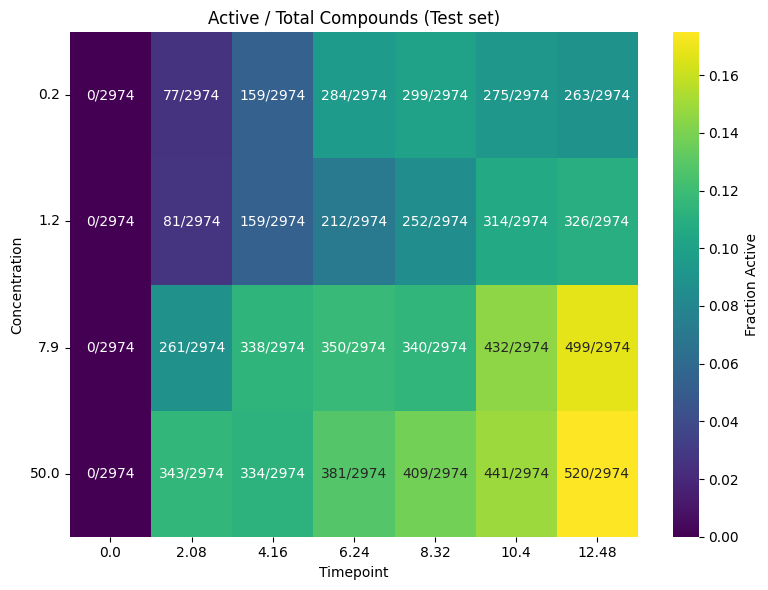

(None, np.int64(9157))

In [18]:
df_GrowthCurve=label_inactives_actives(df_GrowthCurve,mad_multiplier=3)
plot_activity_ratio_heatmap(df_GrowthCurve[df_GrowthCurve['Control_Label'] == 0]),df_GrowthCurve['is_Active'].sum()

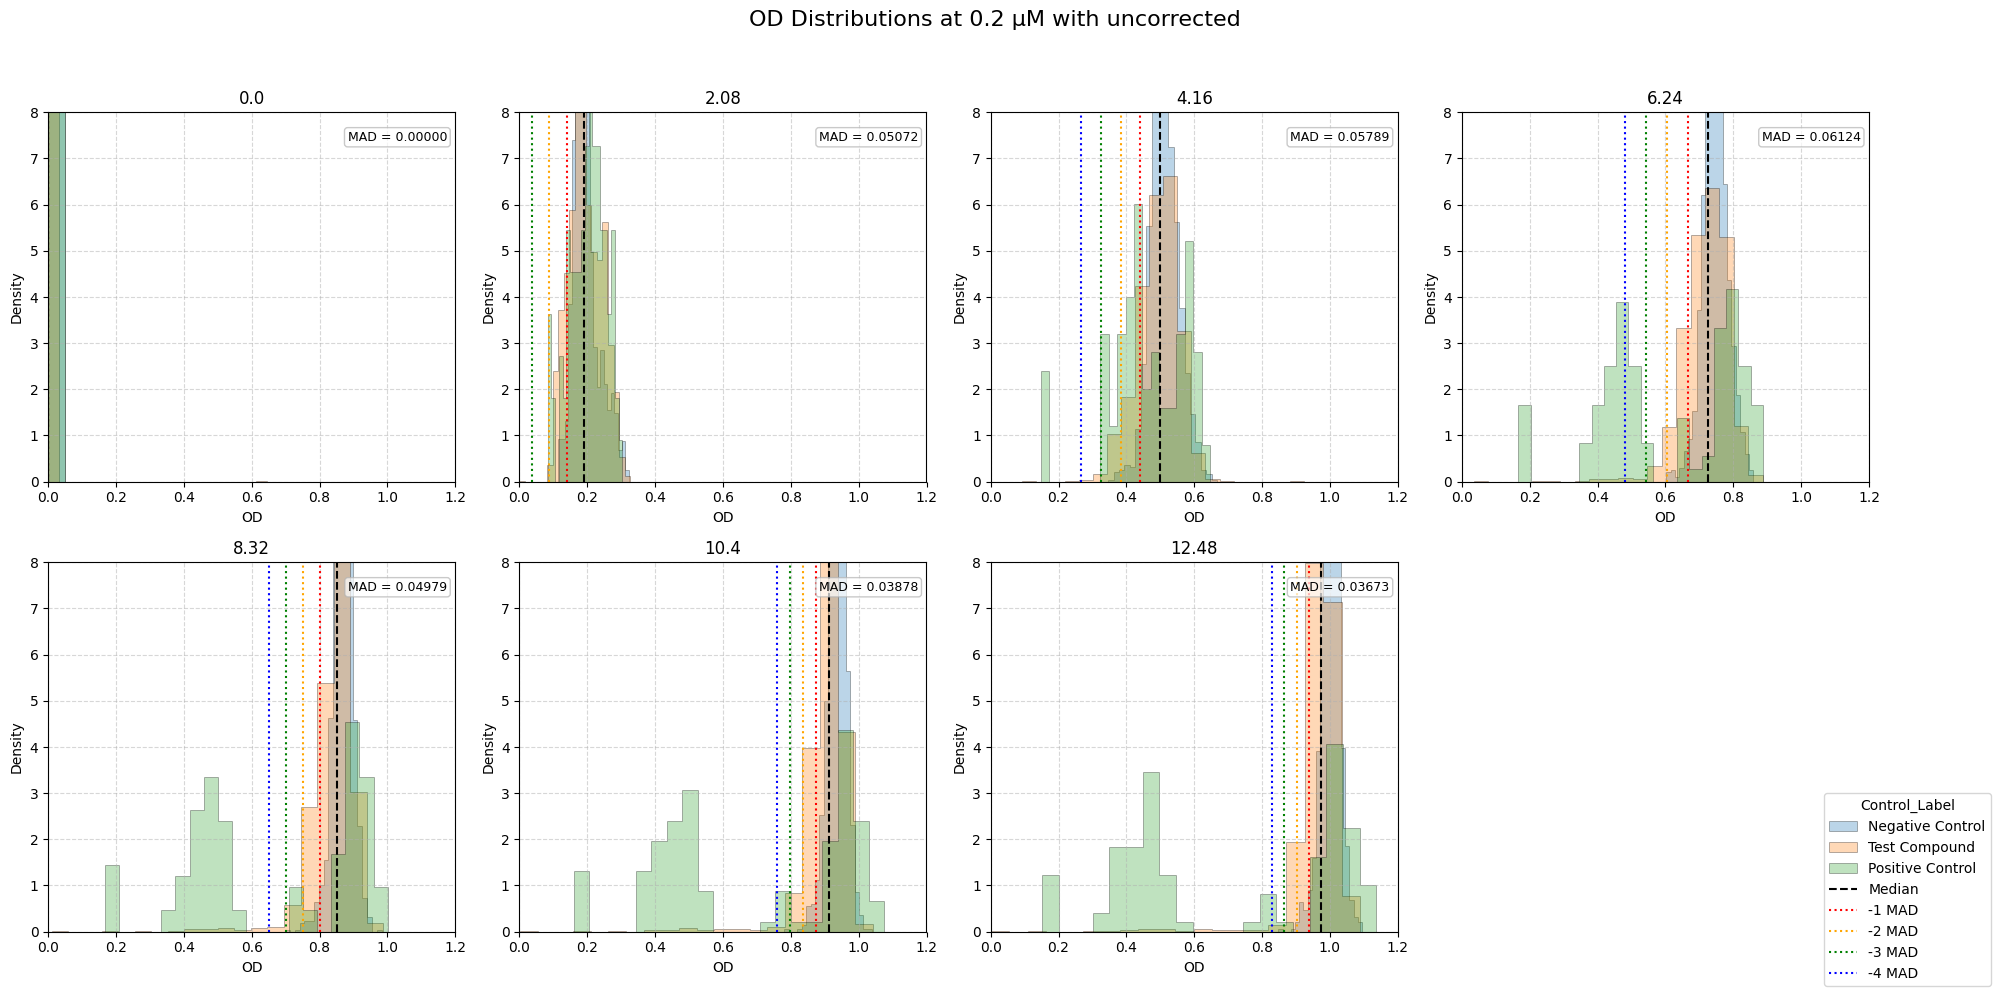

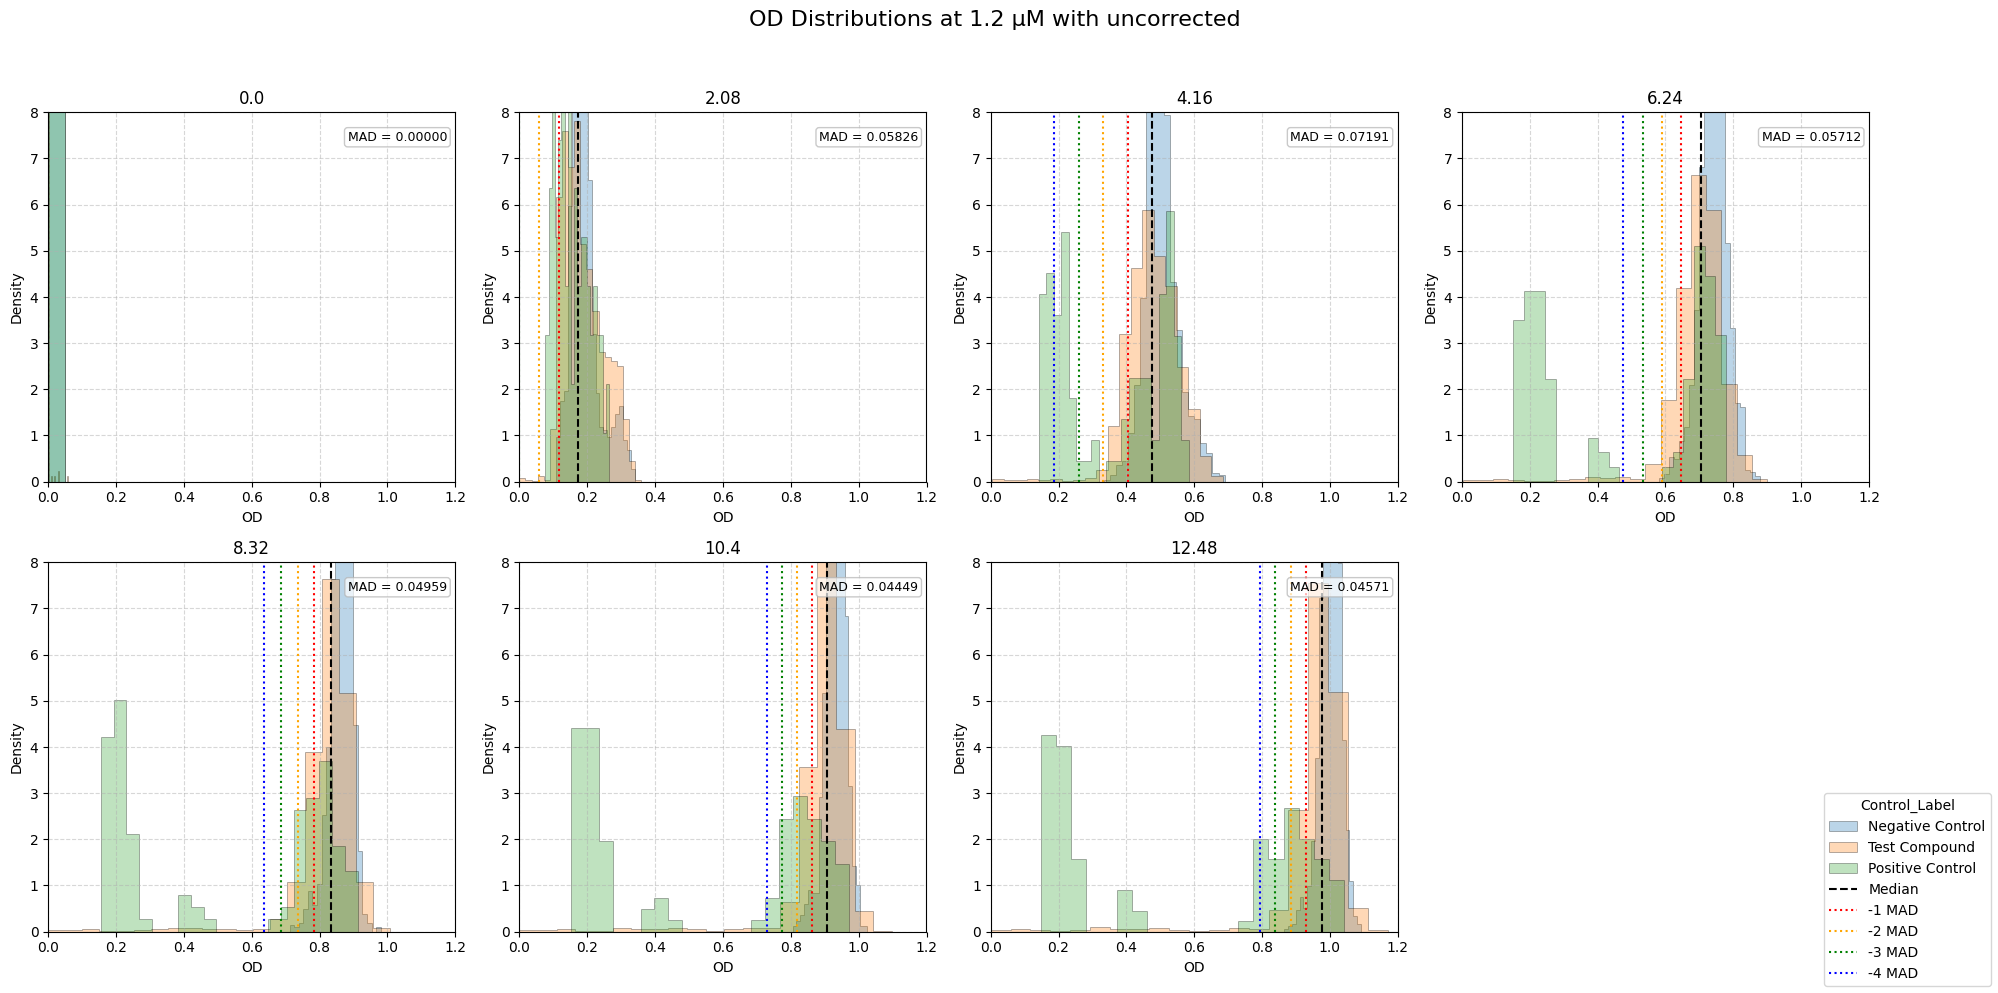

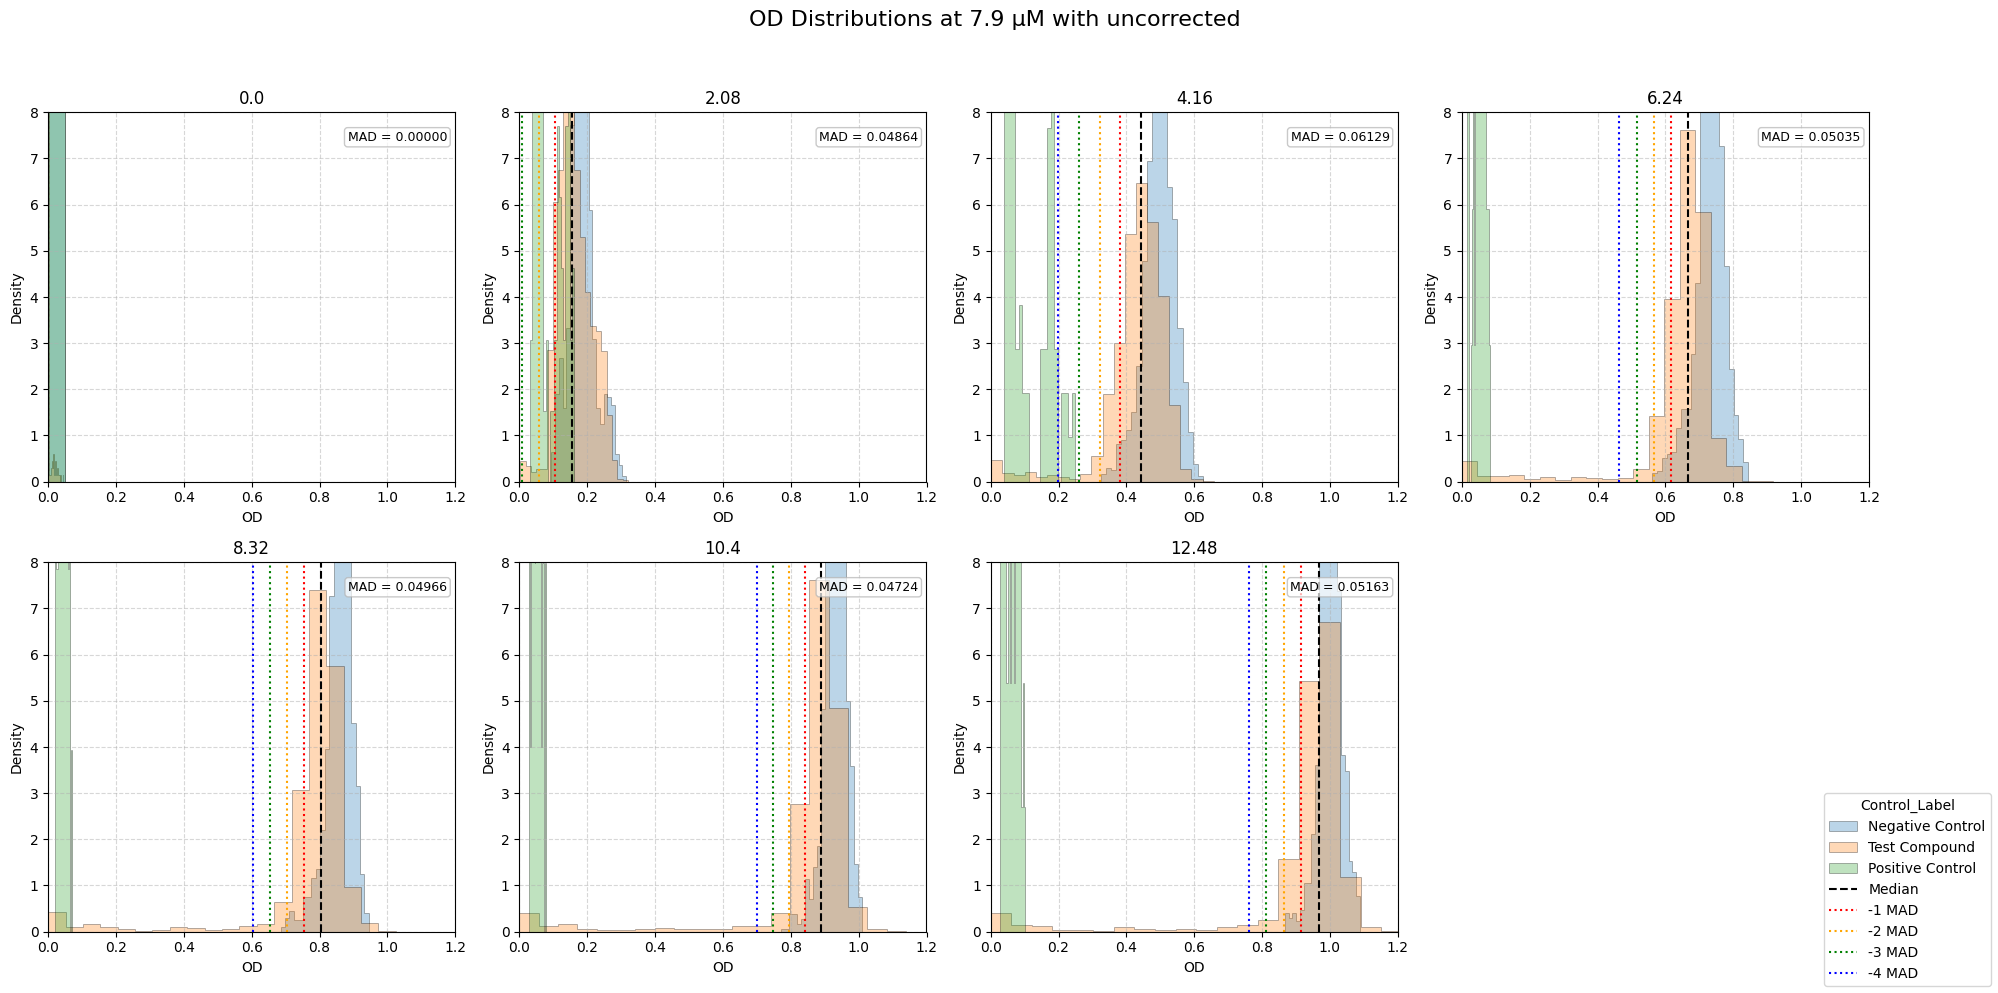

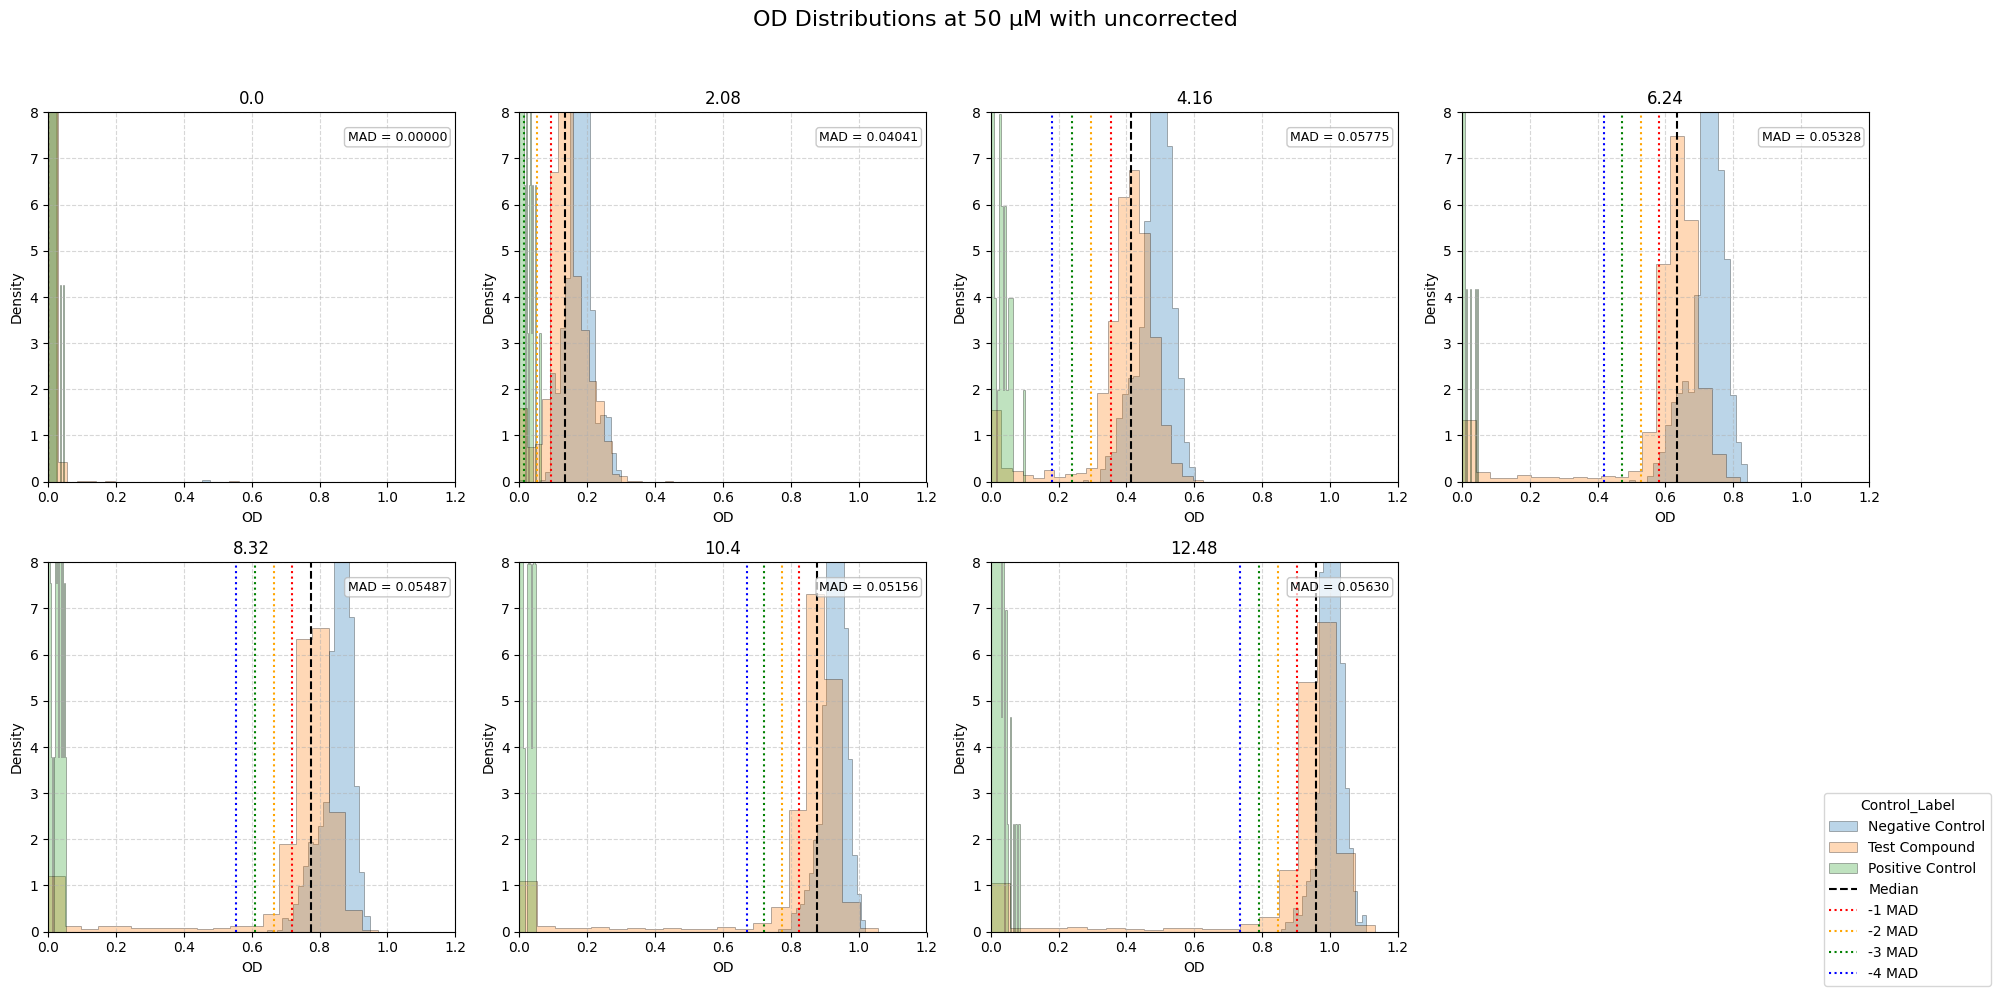

In [19]:
custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}
for c in [0.2, 1.2, 7.9, 50]:
    plot_hist_od_distributions_long(
        title='uncorrected',
        correct_uncorrect='uncorrected',
        dataset='df_GrowthCurve',
        df_long=df_GrowthCurve,
        bins=custom_bins,
        concentration=c,
        max_density=8,
        max_x=1.2,
        save_path=False
    )

## Row and Column Batch effect

In [20]:
df_GrowthCurve_well_corrected_time_conc,global_medians,well_medians = correct_well_batch_effect_time_conc(df_GrowthCurve)

/tmp/ipykernel_835300/3253228211.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


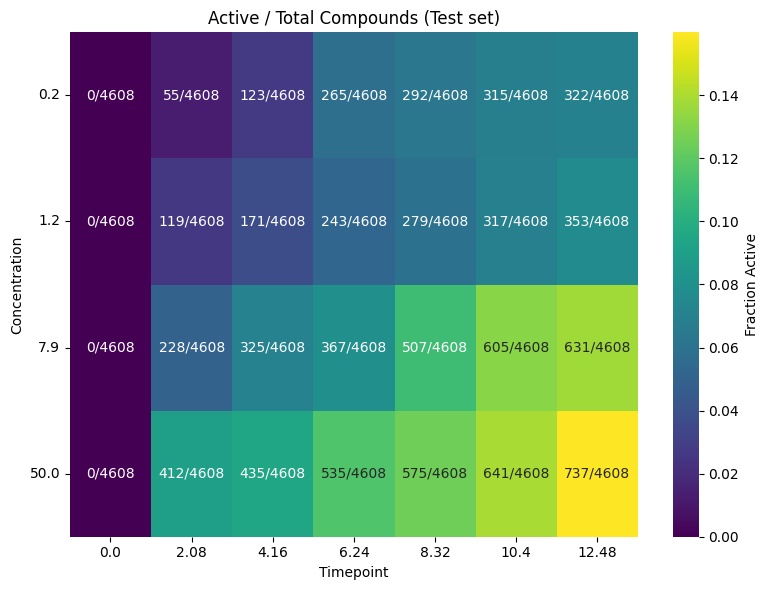

In [21]:
df_GrowthCurve_well_corrected_time_conc=label_inactives_actives(df_GrowthCurve_well_corrected_time_conc,mad_multiplier=3)

plot_activity_ratio_heatmap(df_GrowthCurve_well_corrected_time_conc)

## OD distributions at concentrations

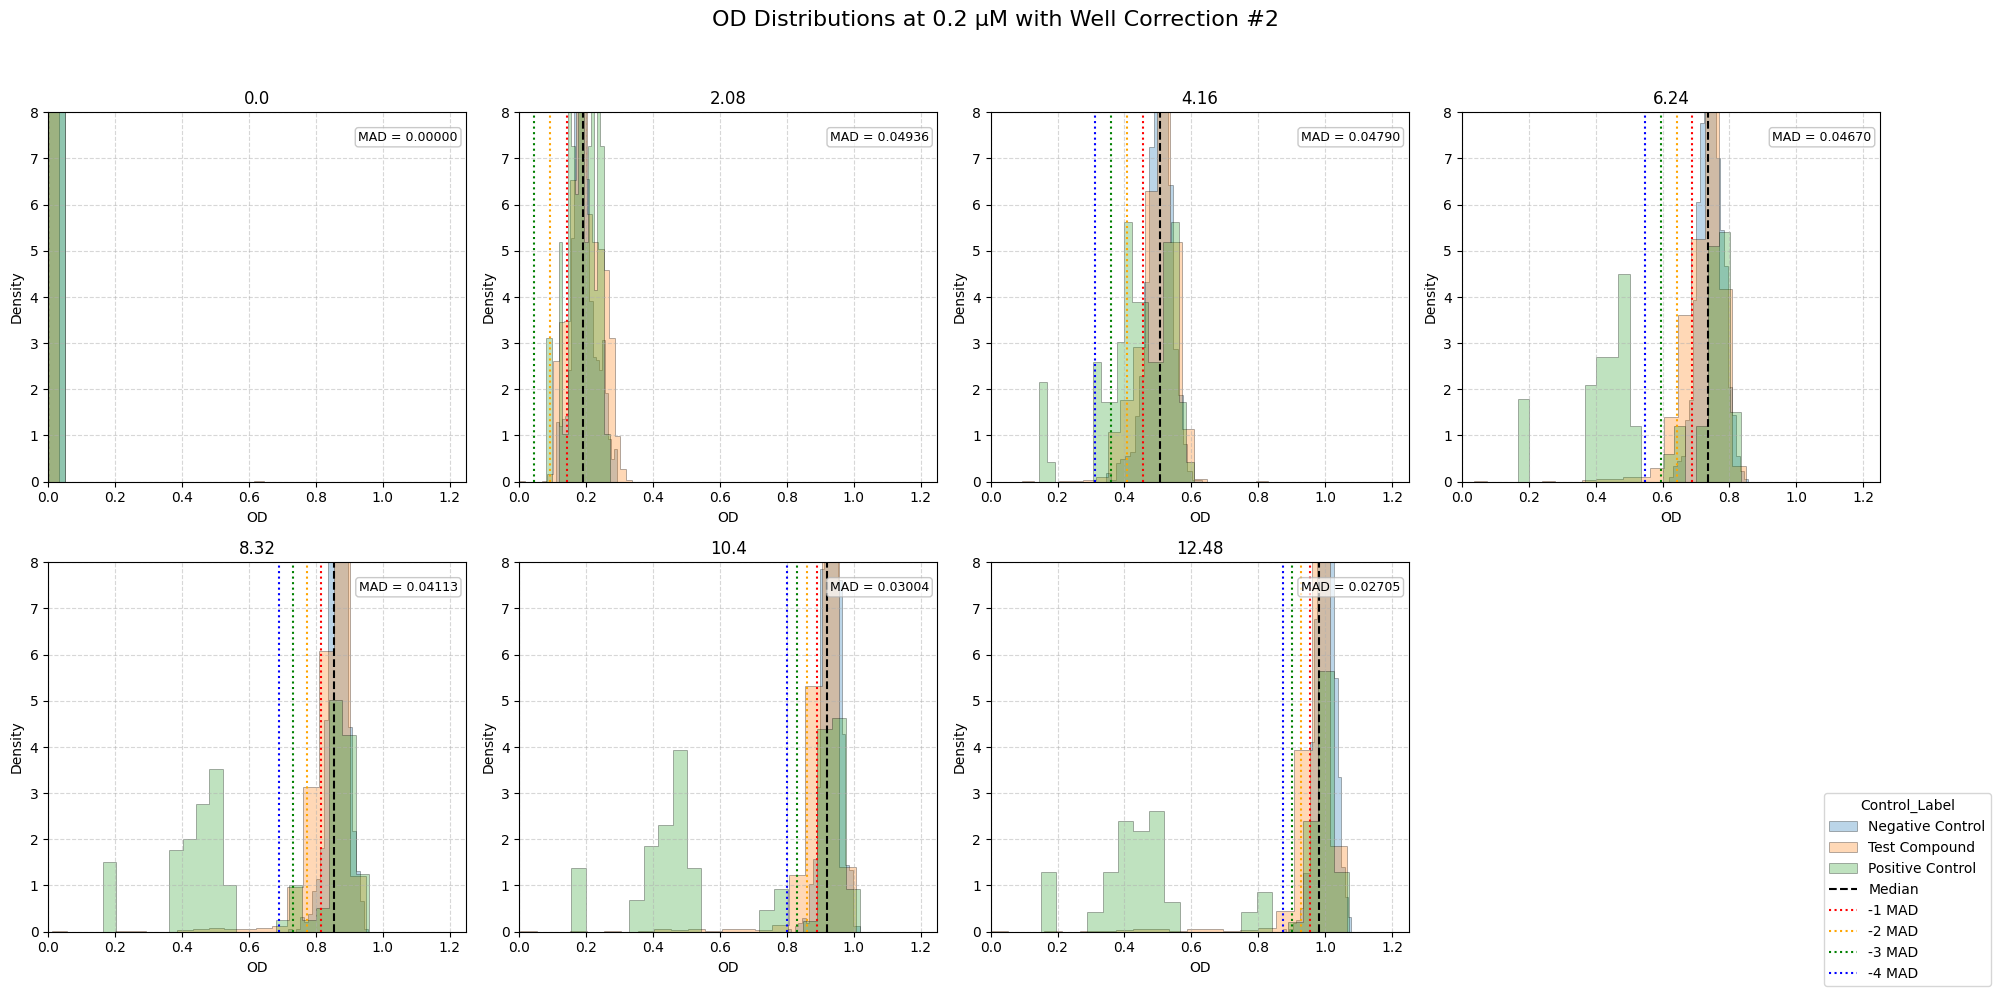

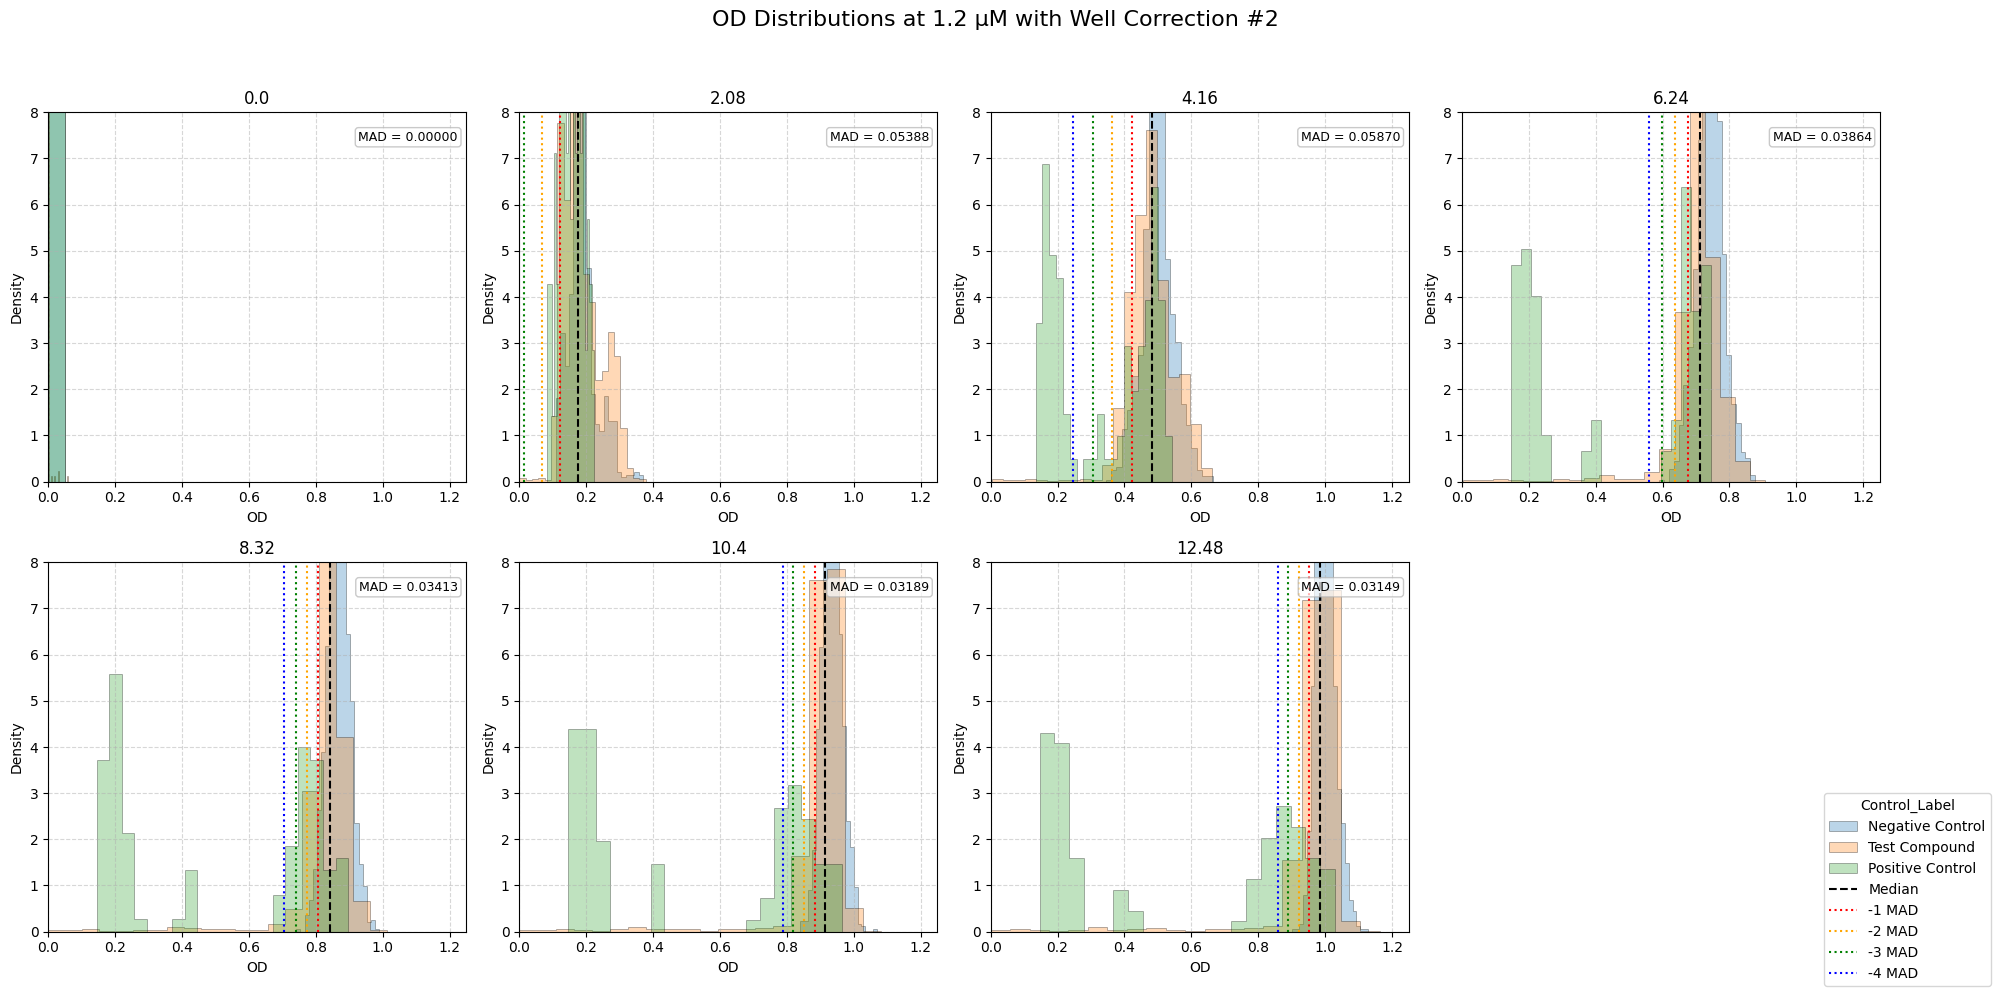

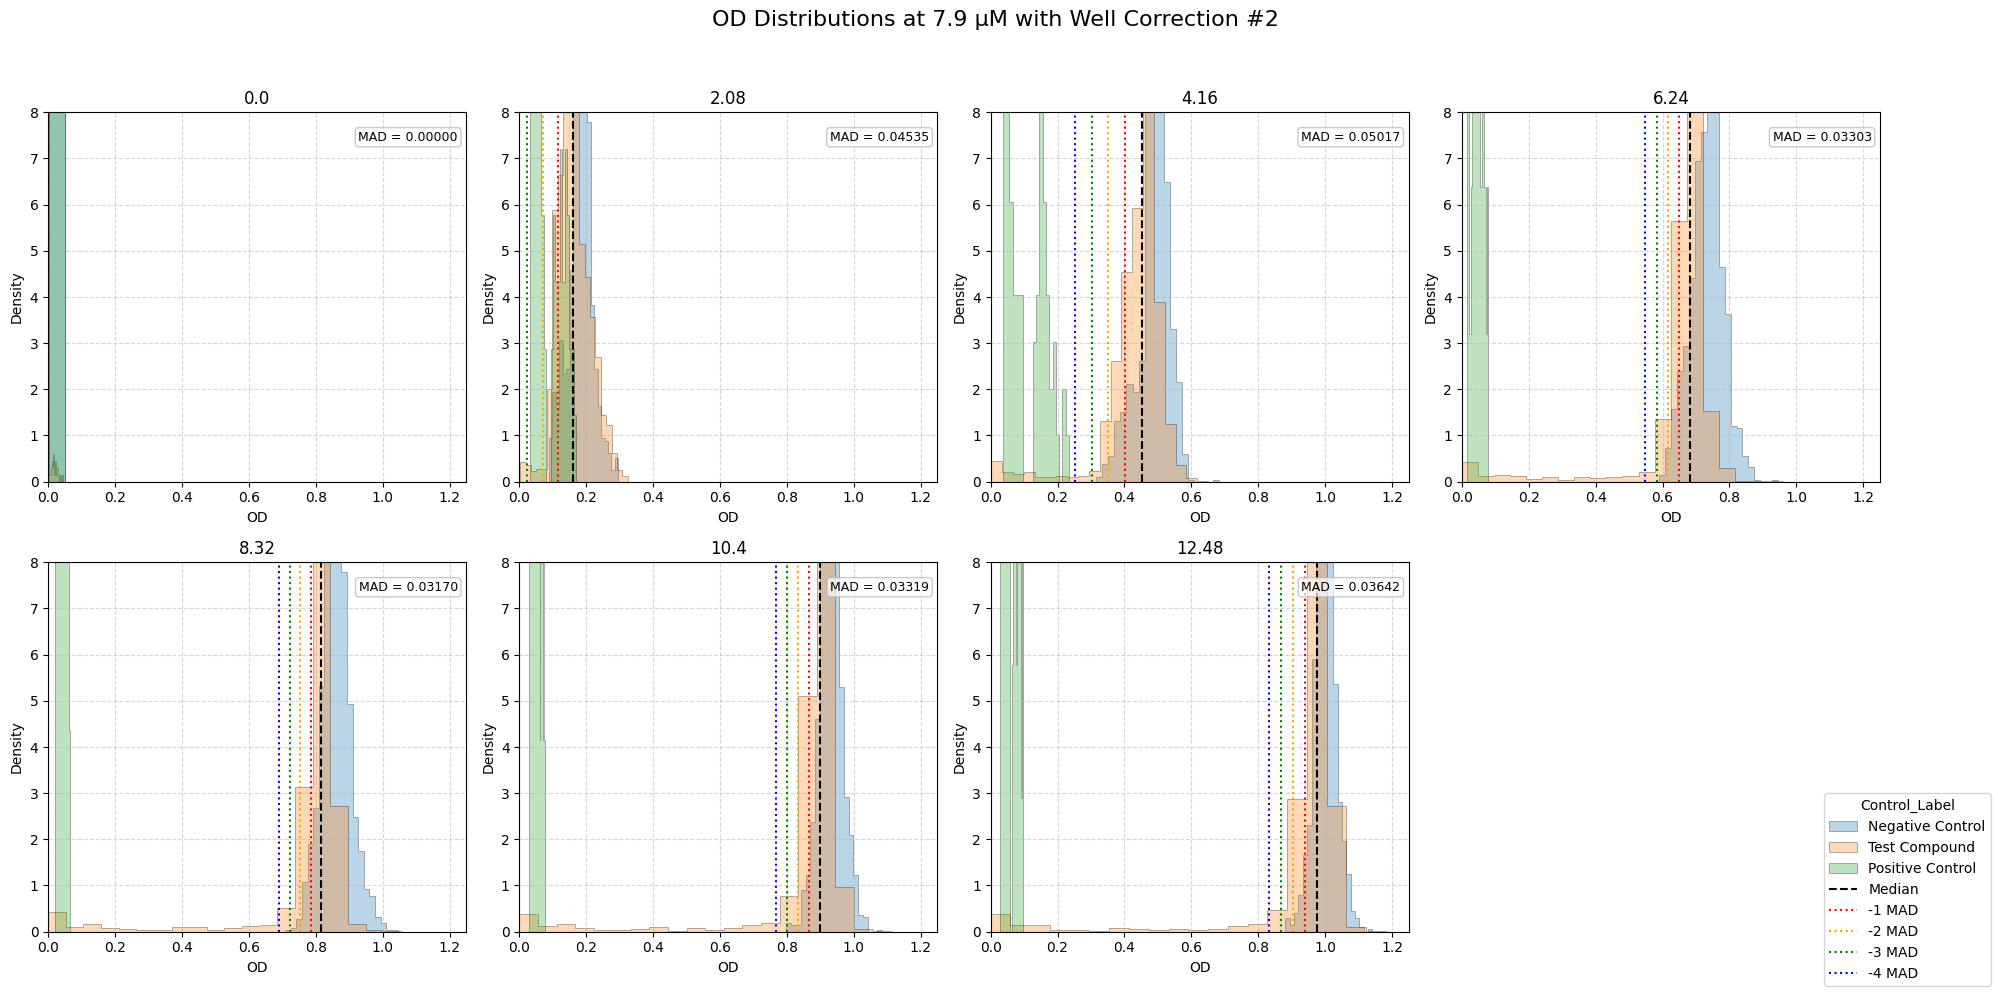

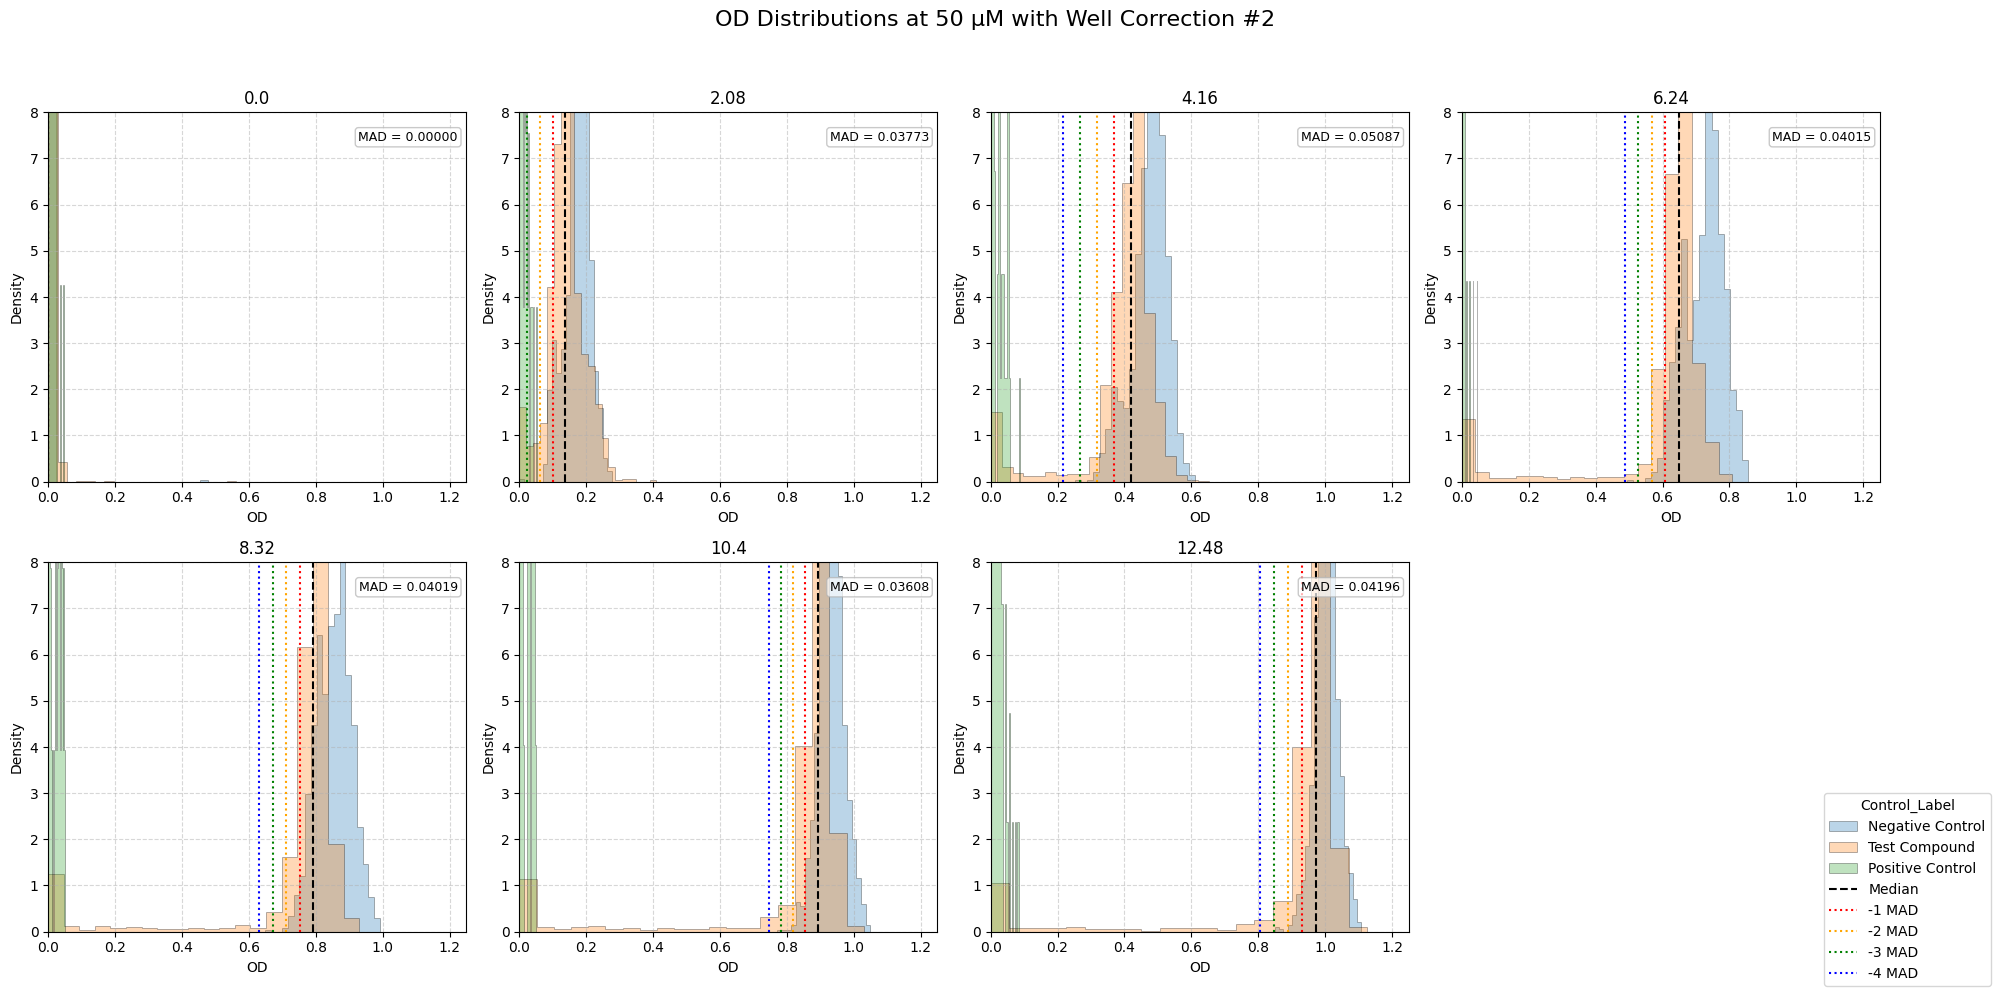

In [22]:
custom_bins = {
    -1: 20,                       # negatives
     0: 20,  # tests
     1: 20,                     # positives
}

title='Well Correction #2'
concentrations=[0.2,1.2,7.9,50]
for c in concentrations:
    plot_hist_od_distributions_long(
        title,
        correct_uncorrect='correction_2',
        dataset='df_GrowthCurve',
        df_long=df_GrowthCurve_well_corrected_time_conc,
        concentration=c,
        bins=custom_bins, 
        max_x=1.25,
        max_density=8,
        save_path=False)

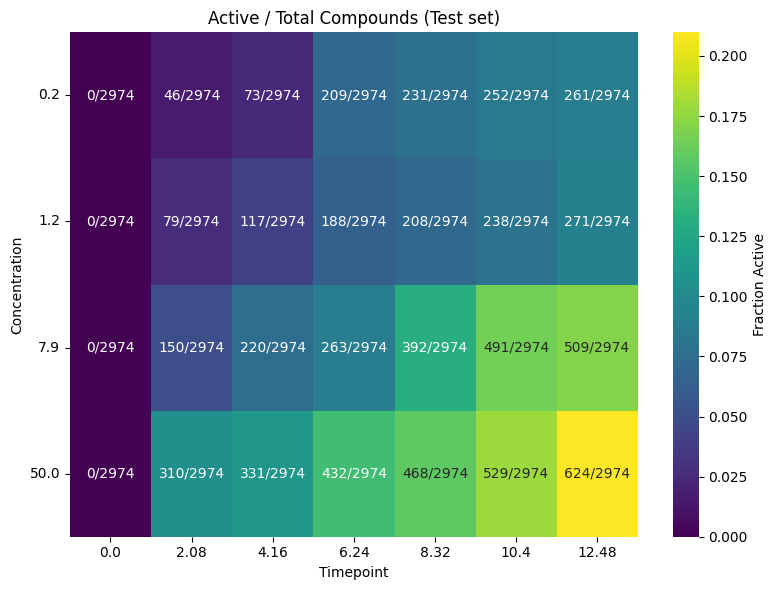

In [23]:
plot_activity_ratio_heatmap(df_GrowthCurve_well_corrected_time_conc[df_GrowthCurve_well_corrected_time_conc['Control_Label'] == 0])